# Customer Churn Prediction

## 📌 Business Problem
A telecom company is facing high customer churn, leading to revenue loss.  
The objective is to identify customers who are likely to churn so that targeted retention strategies can be implemented.

---

## 🎯 Project Objective
- Analyze customer data to identify key factors influencing churn  
- Build a machine learning model to predict churn probability  
- Provide actionable business recommendations to reduce churn  

---

## 📊 Dataset Description
The dataset contains customer-level information such as:
- Demographics (gender, senior citizen, etc.)
- Account information (tenure, contract type)
- Service usage (internet, phone, streaming)
- Billing details (monthly charges, total charges)

Target Variable:
- **Churn (Yes/No)**

---

## 🧠 Approach
This project follows a structured data science workflow:
1. Data Cleaning  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Model Building  
5. Model Evaluation  
6. Business Insights  

---

In [1]:
import pandas as pd 
import numpy as np

In [6]:
df = pd.read_csv('../data/telecom.churn.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df['TotalCharges'].fillna(df['TotalCharges'].median())

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [20]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [21]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 🧹 Data Cleaning

- Converted TotalCharges to numeric format  
- Handled missing values using median  
- Removed irrelevant columns (customerID)  
- Converted target variable (Churn) to binary  

<Axes: xlabel='Churn', ylabel='count'>

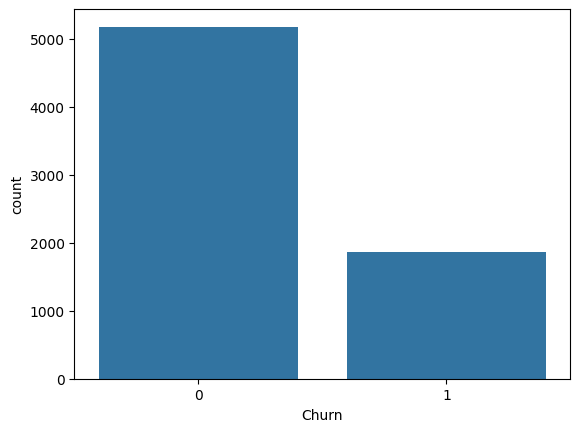

In [22]:
import seaborn as sns
sns.countplot(x='Churn', data = df)

<Axes: xlabel='Churn', ylabel='tenure'>

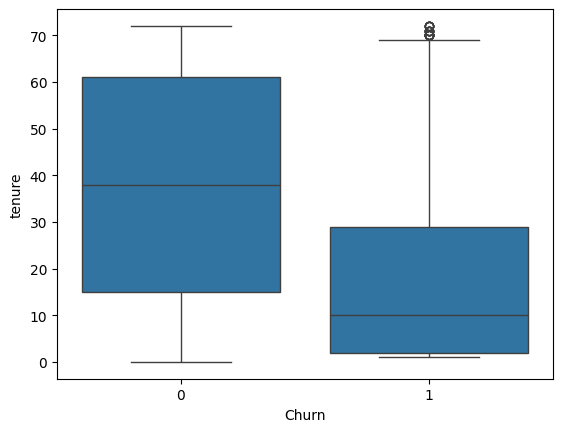

In [23]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [24]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

### 📊 Tenure vs Churn Analysis

- Customers who churn have significantly lower tenure
- Median tenure for churned customers is around 10 months
- Retained customers have much higher tenure (~35+ months)

### 💡 Business Insight
New customers are more likely to churn, indicating the importance of early engagement and retention strategies.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

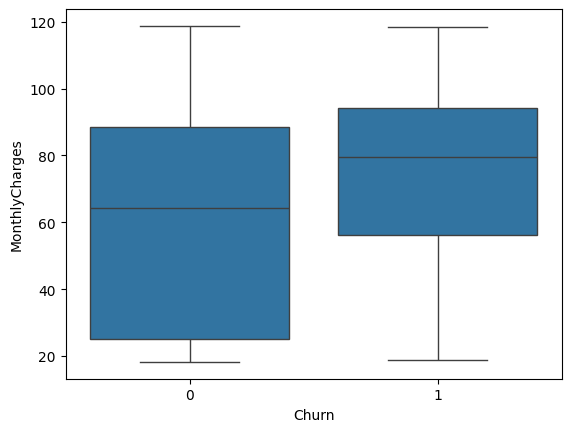

In [26]:
sns.boxplot(x='Churn',y ='MonthlyCharges',data = df)

In [27]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

### 📊 Monthly Charges vs Churn

- Customers who churn have higher average monthly charges
- Indicates a relationship between pricing and churn

### 💡 Business Insight
Higher pricing may lead to dissatisfaction or perceived low value, increasing the likelihood of churn. Pricing optimization or offering better value could help reduce churn.

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

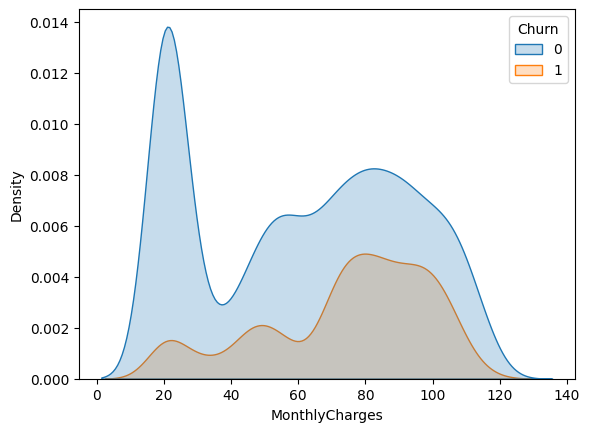

In [29]:
sns.kdeplot(data=df, x= 'MonthlyCharges', hue='Churn', fill =True)

<Axes: xlabel='Contract', ylabel='count'>

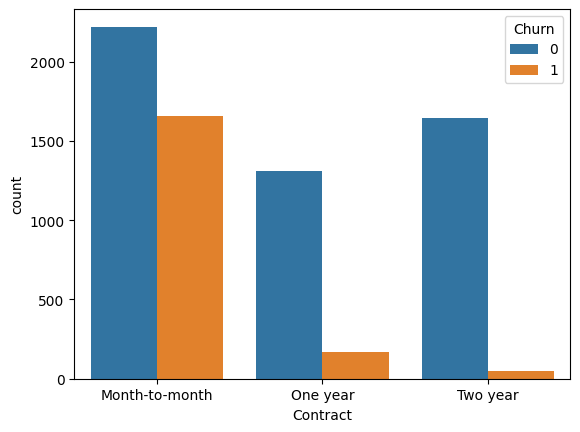

In [30]:
sns.countplot(x='Contract', hue='Churn', data=df)

<Axes: xlabel='PaymentMethod', ylabel='count'>

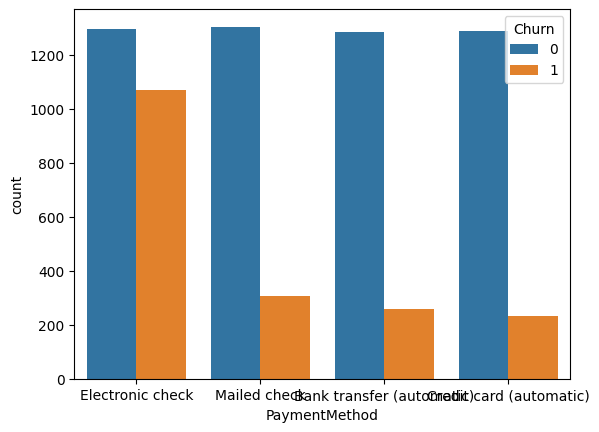

In [31]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

<Axes: xlabel='InternetService', ylabel='count'>

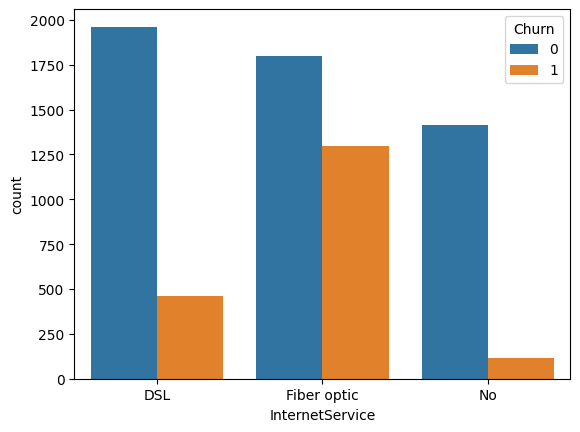

In [32]:
sns.countplot(x='InternetService', hue='Churn', data=df)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

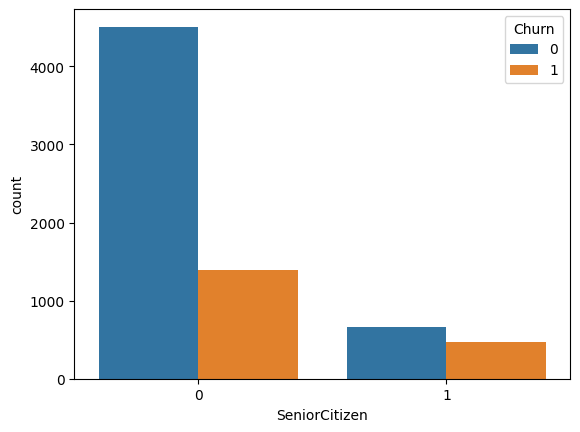

In [33]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

In [35]:
df.groupby('SeniorCitizen')['Churn'].mean() * 100

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

### 📊 Senior Citizen vs Churn

- Senior citizens have a higher churn rate compared to non-senior customers
- Indicates demographic influence on churn behavior

### 💡 Business Insight
Senior customers may need more personalized support and simplified services to improve retention.

## ⚙️ Feature Engineering & Data Preparation

- Converted categorical variables using one-hot encoding  
- Ensured no data leakage by splitting before scaling  
- Prepared dataset for model training and evaluation  

In [37]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).drop('Churn', axis=1).columns

categorical_cols, numerical_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

In [38]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first = True)

In [40]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).drop('Churn', axis=1).columns.tolist()

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [47]:
import pickle

pickle.dump(pipeline, open('../models/churn_pipeline.pkl', 'wb'))

In [48]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

### ⚖️ Handling Class Imbalance

- Applied class_weight='balanced' to improve recall for churn class  
- Ensured better detection of high-risk customers  

In [52]:
y_prob = pipeline.predict_proba(X_test)[:,1]
y_pred_custom = (y_prob > 0.3).astype(int)

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1036
           1       0.55      0.75      0.63       373

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



### 🎯 Threshold Tuning

- Adjusted classification threshold from 0.5 to 0.3  
- Improved recall to better identify churn customers  
- Accepted trade-off of lower precision for higher recall  

### 💡 Business Insight
Lowering the threshold allows the business to identify more high-risk customers, enabling proactive retention strategies.

In [55]:
model = pipeline.named_steps['model']
importances = model.feature_importances_

# Get feature names from preprocessor
ohe = pipeline.named_steps['preprocessing'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out()

all_features = list(numerical_cols) + list(encoded_features)

import pandas as pd

feature_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_df.head(10)

,Feature,Importance
3,TotalCharges,0.181463
1,tenure,0.164993
2,MonthlyCharges,0.154006
25,Contract_Two year,0.060031
10,InternetService_Fiber optic,0.038133
28,PaymentMethod_Electronic check,0.036116
24,Contract_One year,0.028965
13,OnlineSecurity_Yes,0.028112
4,gender_Male,0.024477
26,PaperlessBilling_Yes,0.024151


### 🔍 Key Drivers of Churn

- Contract type, tenure, and monthly charges are the most influential features  
- Model insights align with EDA findings, validating feature relevance  